# Greco1899 data understanding

**Source:** UFCStats, via the Greco1899/scrape_ufc_stats GitHub repository (daily auto-refresh)

**Package:** pandas (direct CSV reads from raw.githubusercontent.com); matplotlib for charts

**Run date:** 2026-05-04 (Part 1); Part 2 added 2026-05-09

This notebook establishes an understanding of the primary structured data source before any modelling. It works in two parts. The first validates the schema and the method and outcome taxonomies, reconciles the fighter counts across the two fighter tables, and extracts the canonical IDs the later joins depend on. The second examines the distributions the modelling relies on: the distribution of fights per fighter behind the reliability thresholds, coverage over time, and the string parsing assumptions the later numeric conversion is built on.

**Data provenance.** This notebook reads the Greco1899 repository live, which auto-refreshes daily, so a re-run reflects the repository on the day it is run rather than the analytical freeze. The Greco mirror stalled in mid-May 2026 and was superseded by the project's own UFCStats scraper (deviation log C.8); the canonical dataset for all modelling is the frozen snapshot taken at 11 July 2026 (UFC 329), held in the project's data repository, not the live feed read here. This notebook is retained as the initial data-understanding pass on the primary source; its live counts may differ from the frozen figures used downstream, which is expected and not a discrepancy.

**Use in project:** Primary structured data source for both axes. Data at the fight level drives the Glicko-2 competitive ratings; statistics at the round level drive the GMM style clustering, a diagnostic layer; fighter details and tale of the tape provide the physical attribute context used only on the diagnostic layer.

## Part 1: Schema validation, taxonomy checks, ID extraction

Loads the six CSVs, confirms each file's column structure matches what the modelling expects, validates the method and outcome taxonomies that determine which bouts enter the rating system, reconciles the fighter counts across the two fighter tables, and extracts canonical IDs from the URL hashes for the joins the later stages depend on.

In [ ]:
# BLOCK 1: Install libraries and initial setup + Pull UFCStats data from the Greco1899 repo

import pandas as pd
import io
import requests
import matplotlib.pyplot as plt
import re

# dataframe config
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

BASE_URL = "https://raw.githubusercontent.com/Greco1899/scrape_ufc_stats/main/"

# csv file names from repo
FILES = [
    "ufc_event_details.csv",
    "ufc_fight_details.csv",
    "ufc_fight_results.csv",
    "ufc_fight_stats.csv",
    "ufc_fighter_details.csv",
    "ufc_fighter_tott.csv",
]

print(f"Checking {len(FILES)} CSV files from Greco1899/scrape_ufc_stats")
print(f"Base URL: {BASE_URL}")

Checking 6 CSV files from Greco1899/scrape_ufc_stats
Base URL: https://raw.githubusercontent.com/Greco1899/scrape_ufc_stats/main/


In [ ]:
# BLOCK 2: merge files into DF dictionary

dataframes = {}

for filename in FILES:
    url = BASE_URL + filename
    try:
        # CSV to Pandas from URL
        df = pd.read_csv(url)
        dataframes[filename] = df
        print(f"OK   {filename:30s}  shape: {df.shape}  columns: {len(df.columns)}")
    except Exception as e:
        # Name file if error
        print(f"FILE {filename:30s}  error: {e}")

print(f"\nSuccessfully loaded {len(dataframes)} of {len(FILES)} files")

OK   ufc_event_details.csv           shape: (781, 4)  columns: 4
OK   ufc_fight_details.csv           shape: (8796, 3)  columns: 3
OK   ufc_fight_results.csv           shape: (8796, 11)  columns: 11
OK   ufc_fight_stats.csv             shape: (41400, 19)  columns: 19
OK   ufc_fighter_details.csv         shape: (4573, 4)  columns: 4
OK   ufc_fighter_tott.csv            shape: (4574, 7)  columns: 7

Successfully loaded 6 of 6 files


In [ ]:
# BLOCK 3: Inspect ufc_event_details.csv

df_events = dataframes["ufc_event_details.csv"]

print("COLUMNS")
print(df_events.columns.tolist())
print()

print("DATA TYPES")
print(df_events.dtypes)
print()

print("First 5 Rows")
df_events.head()

COLUMNS
['EVENT', 'URL', 'DATE', 'LOCATION']

DATA TYPES
EVENT       object
URL         object
DATE        object
LOCATION    object
dtype: object

First 5 Rows


,EVENT,URL,DATE,LOCATION
0,UFC Fight Night: Ankalaev vs. Guskov,http://ufcstats.com/event-details/681d07e32879...,"July 25, 2026","Abu Dhabi, Abu Dhabi, United Arab Emirates"
1,UFC Fight Night: Du Plessis vs. Usman,http://ufcstats.com/event-details/f354c50b8d63...,"July 18, 2026","Oklahoma City, Oklahoma, USA"
2,UFC 329: McGregor vs. Holloway 2,http://ufcstats.com/event-details/fccb0fee256b...,"July 11, 2026","Las Vegas, Nevada, USA"
3,UFC Fight Night: Fiziev vs. Torres,http://ufcstats.com/event-details/31e1ea6fe6b6...,"June 27, 2026","Baku, Azerbaijan"
4,UFC Fight Night: Kape vs. Horiguchi,http://ufcstats.com/event-details/c8661e204c66...,"June 20, 2026","Las Vegas, Nevada, USA"


In [ ]:
# BLOCK 4: Inspect ufc_fight_details.csv

df_fight_details = dataframes["ufc_fight_details.csv"]

print("COLUMNS")
print(df_fight_details.columns.tolist())
print()

print("DATATYPES")
print(df_fight_details.dtypes)
print()

print("First 5 rows")
df_fight_details.head()

COLUMNS
['EVENT', 'BOUT', 'URL']

DATATYPES
EVENT    object
BOUT     object
URL      object
dtype: object

First 5 rows


,EVENT,BOUT,URL
0,UFC Fight Night: Ankalaev vs. Guskov,Magomed Ankalaev vs. Bogdan Guskov,http://ufcstats.com/fight-details/9009ec7b91f2...
1,UFC Fight Night: Ankalaev vs. Guskov,Steve Erceg vs. Ramazan Temirov,http://ufcstats.com/fight-details/c36cd04f8f56...
2,UFC Fight Night: Ankalaev vs. Guskov,Magomed Zaynukov vs. Damian Rzepecki,http://ufcstats.com/fight-details/4ace64aa1443...
3,UFC Fight Night: Ankalaev vs. Guskov,Rizvan Kuniev vs. Tyrell Fortune,http://ufcstats.com/fight-details/5ffb251c6ea4...
4,UFC Fight Night: Ankalaev vs. Guskov,Abubakar Vagaev vs. Saygid Izagakhmaev,http://ufcstats.com/fight-details/61280e564418...


In [ ]:
# BLOCK 5: Inspect ufc_fight_results.csv

df_fight_results = dataframes["ufc_fight_results.csv"]

print("COLUMNS")
print(df_fight_results.columns.tolist())
print()

print("DATATYPES")
print(df_fight_results.dtypes)
print()

print("First 5 rows")
df_fight_results.head()

COLUMNS
['EVENT', 'BOUT', 'OUTCOME', 'WEIGHTCLASS', 'METHOD', 'ROUND', 'TIME', 'TIME FORMAT', 'REFEREE', 'DETAILS', 'URL']

DATATYPES
EVENT          object
BOUT           object
OUTCOME        object
WEIGHTCLASS    object
METHOD         object
ROUND           int64
TIME           object
TIME FORMAT    object
REFEREE        object
DETAILS        object
URL            object
dtype: object

First 5 rows


,EVENT,BOUT,OUTCOME,WEIGHTCLASS,METHOD,ROUND,TIME,TIME FORMAT,REFEREE,DETAILS,URL
0,UFC Fight Night: Ankalaev vs. Guskov,Magomed Ankalaev vs. Bogdan Guskov,W/L,Light Heavyweight Bout,KO/TKO,5,2:41,5 Rnd (5-5-5-5-5),Marc Goddard,Punches to Head On Ground,http://ufcstats.com/fight-details/9009ec7b91f2...
1,UFC Fight Night: Ankalaev vs. Guskov,Steve Erceg vs. Ramazan Temirov,L/W,Flyweight Bout,KO/TKO,1,4:21,3 Rnd (5-5-5),Mike Beltran,Punches to Head At Distance,http://ufcstats.com/fight-details/c36cd04f8f56...
2,UFC Fight Night: Ankalaev vs. Guskov,Magomed Zaynukov vs. Damian Rzepecki,W/L,Lightweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Marc Goddard,Ben Cartlidge 27 - 30.Vito Paolillo 27 - 30.Ce...,http://ufcstats.com/fight-details/4ace64aa1443...
3,UFC Fight Night: Ankalaev vs. Guskov,Rizvan Kuniev vs. Tyrell Fortune,W/L,Heavyweight Bout,KO/TKO,3,1:12,3 Rnd (5-5-5),Jim Perdios,Knee to Head In Clinch,http://ufcstats.com/fight-details/5ffb251c6ea4...
4,UFC Fight Night: Ankalaev vs. Guskov,Abubakar Vagaev vs. Saygid Izagakhmaev,W/L,Welterweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Mike Beltran,Vito Paolillo 28 - 29.Clemens Werner 28 - 29.C...,http://ufcstats.com/fight-details/61280e564418...


In [ ]:
# BLOCK 6: Inspect ufc_fight_stats.csv

df_fight_stats = dataframes["ufc_fight_stats.csv"]

print("COLUMNS")
print(df_fight_stats.columns.tolist())
print()

print("DATATYPES")
print(df_fight_stats.dtypes)
print()

print("First 5 rows")
df_fight_stats.head()

COLUMNS
['EVENT', 'BOUT', 'ROUND', 'FIGHTER', 'KD', 'SIG.STR.', 'SIG.STR. %', 'TOTAL STR.', 'TD', 'TD %', 'SUB.ATT', 'REV.', 'CTRL', 'HEAD', 'BODY', 'LEG', 'DISTANCE', 'CLINCH', 'GROUND']

DATATYPES
EVENT          object
BOUT           object
ROUND          object
FIGHTER        object
KD            float64
SIG.STR.       object
SIG.STR. %     object
TOTAL STR.     object
TD             object
TD %           object
SUB.ATT       float64
REV.          float64
CTRL           object
HEAD           object
BODY           object
LEG            object
DISTANCE       object
CLINCH         object
GROUND         object
dtype: object

First 5 rows


,EVENT,BOUT,ROUND,FIGHTER,KD,SIG.STR.,SIG.STR. %,TOTAL STR.,TD,TD %,SUB.ATT,REV.,CTRL,HEAD,BODY,LEG,DISTANCE,CLINCH,GROUND
0,UFC Fight Night: Ankalaev vs. Guskov,Magomed Ankalaev vs. Bogdan Guskov,Round 1,Magomed Ankalaev,0.0,19 of 39,48%,19 of 39,0 of 1,0%,0.0,0.0,0:00,2 of 18,13 of 16,4 of 5,19 of 39,0 of 0,0 of 0
1,UFC Fight Night: Ankalaev vs. Guskov,Magomed Ankalaev vs. Bogdan Guskov,Round 2,Magomed Ankalaev,0.0,14 of 29,48%,29 of 44,0 of 1,0%,0.0,0.0,1:21,6 of 18,8 of 11,0 of 0,10 of 25,4 of 4,0 of 0
2,UFC Fight Night: Ankalaev vs. Guskov,Magomed Ankalaev vs. Bogdan Guskov,Round 3,Magomed Ankalaev,0.0,15 of 33,45%,15 of 33,0 of 0,---,0.0,0.0,0:00,5 of 15,5 of 12,5 of 6,15 of 33,0 of 0,0 of 0
3,UFC Fight Night: Ankalaev vs. Guskov,Magomed Ankalaev vs. Bogdan Guskov,Round 4,Magomed Ankalaev,0.0,3 of 5,60%,56 of 69,1 of 1,100%,3.0,0.0,4:50,3 of 5,0 of 0,0 of 0,0 of 1,0 of 0,3 of 4
4,UFC Fight Night: Ankalaev vs. Guskov,Magomed Ankalaev vs. Bogdan Guskov,Round 5,Magomed Ankalaev,0.0,3 of 7,42%,37 of 50,1 of 1,100%,0.0,0.0,2:15,3 of 7,0 of 0,0 of 0,0 of 0,0 of 0,3 of 7


In [ ]:
# BLOCK 7: Inspect ufc_fighter_details.csv

# Note: Fighter database

df_fighter_details = dataframes["ufc_fighter_details.csv"]

print("COLUMNS")
print(df_fighter_details.columns.tolist())
print()

print("DATATYPES")
print(df_fighter_details.dtypes)
print()

print("First 5 rows")
df_fighter_details.head()

COLUMNS
['FIRST', 'LAST', 'NICKNAME', 'URL']

DATATYPES
FIRST       object
LAST        object
NICKNAME    object
URL         object
dtype: object

First 5 rows


,FIRST,LAST,NICKNAME,URL
0,Tom,Aaron,NaN,http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny,Abbadi,The Assassin,http://ufcstats.com/fighter-details/15df64c02b...
2,Nariman,Abbasov,Bayraktar,http://ufcstats.com/fighter-details/59a9d6dac6...
3,Darion,Abbey,NaN,http://ufcstats.com/fighter-details/4961467134...
4,David,Abbott,Tank,http://ufcstats.com/fighter-details/b361180739...


In [ ]:
# BLOCK 8: Inspect ufc_fighter_tott.csv

# Note: Fighter Database 2

df_fighter_tott = dataframes["ufc_fighter_tott.csv"]

print("COLUMNS")
print(df_fighter_tott.columns.tolist())
print()

print("DATATYPES")
print(df_fighter_tott.dtypes)
print()

print("First 5 rows")
df_fighter_tott.head()

COLUMNS
['FIGHTER', 'HEIGHT', 'WEIGHT', 'REACH', 'STANCE', 'DOB', 'URL']

DATATYPES
FIGHTER    object
HEIGHT     object
WEIGHT     object
REACH      object
STANCE     object
DOB        object
URL        object
dtype: object

First 5 rows


,FIGHTER,HEIGHT,WEIGHT,REACH,STANCE,DOB,URL
0,Tom Aaron,--,155 lbs.,--,NaN,"Jul 13, 1978",http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny Abbadi,"5' 11""",155 lbs.,--,Orthodox,"Jul 03, 1983",http://ufcstats.com/fighter-details/15df64c02b...
2,Nariman Abbasov,"5' 8""",155 lbs.,"66""",Orthodox,"Feb 01, 1994",http://ufcstats.com/fighter-details/59a9d6dac6...
3,Darion Abbey,"6' 2""",265 lbs.,"80""",Orthodox,"Feb 25, 1993",http://ufcstats.com/fighter-details/4961467134...
4,David Abbott,"6' 0""",265 lbs.,--,Switch,"Apr 26, 1965",http://ufcstats.com/fighter-details/b361180739...


In [ ]:
# BLOCK 9: Data Summary

print("UFCSTATS DATA INVENTORY (Greco1899 repo)")
print()

for filename, df in dataframes.items():
    print(f"FILE: {filename}")
    print(f"   Rows: {len(df):,}    Columns: {len(df.columns)}")
    print(f"   Columns: {df.columns.tolist()}")
    print()

print(f"TOTAL: {sum(len(df) for df in dataframes.values()):,} rows across {len(dataframes)} files")

UFCSTATS DATA INVENTORY (Greco1899 repo)

FILE: ufc_event_details.csv
   Rows: 781    Columns: 4
   Columns: ['EVENT', 'URL', 'DATE', 'LOCATION']

FILE: ufc_fight_details.csv
   Rows: 8,796    Columns: 3
   Columns: ['EVENT', 'BOUT', 'URL']

FILE: ufc_fight_results.csv
   Rows: 8,796    Columns: 11
   Columns: ['EVENT', 'BOUT', 'OUTCOME', 'WEIGHTCLASS', 'METHOD', 'ROUND', 'TIME', 'TIME FORMAT', 'REFEREE', 'DETAILS', 'URL']

FILE: ufc_fight_stats.csv
   Rows: 41,400    Columns: 19
   Columns: ['EVENT', 'BOUT', 'ROUND', 'FIGHTER', 'KD', 'SIG.STR.', 'SIG.STR. %', 'TOTAL STR.', 'TD', 'TD %', 'SUB.ATT', 'REV.', 'CTRL', 'HEAD', 'BODY', 'LEG', 'DISTANCE', 'CLINCH', 'GROUND']

FILE: ufc_fighter_details.csv
   Rows: 4,573    Columns: 4
   Columns: ['FIRST', 'LAST', 'NICKNAME', 'URL']

FILE: ufc_fighter_tott.csv
   Rows: 4,574    Columns: 7
   Columns: ['FIGHTER', 'HEIGHT', 'WEIGHT', 'REACH', 'STANCE', 'DOB', 'URL']

TOTAL: 68,920 rows across 6 files


In [ ]:
# BLOCK 10 Data check on important files

print("Method taxonomy")
print(df_fight_results['METHOD'].value_counts())
print()

print("Outcome taxonomy")
print(df_fight_results['OUTCOME'].value_counts())
print()

print("Fighter count consistency")
print(f"Fighters in fighter_details: {len(df_fighter_details)}")
print(f"Fighters in fighter_tott: {len(df_fighter_tott)}")
print(f"Unique fighters in fight_stats: {df_fight_stats['FIGHTER'].nunique()}")
print()

print("Sample of weight class values")
print(df_fight_results['WEIGHTCLASS'].value_counts().head(20))

Method taxonomy
METHOD
Decision - Unanimous        3163
KO/TKO                      2780
Submission                  1707
Decision - Split             828
Decision - Majority          104
TKO - Doctor's Stoppage       98
Overturned                    58
Could Not Continue            33
DQ                            23
Other                          2
Name: count, dtype: int64

Outcome taxonomy
OUTCOME
W/L      5541
L/W      3100
NC/NC      90
D/D        65
Name: count, dtype: int64

Fighter count consistency
Fighters in fighter_details: 4573
Fighters in fighter_tott: 4574
Unique fighters in fight_stats: 2708

Sample of weight class values
WEIGHTCLASS
Lightweight Bout                    1412
Welterweight Bout                   1341
Middleweight Bout                   1103
Featherweight Bout                   841
Bantamweight Bout                    758
Heavyweight Bout                     717
Light Heavyweight Bout               703
Flyweight Bout                       394
Women's Straw

In [ ]:
# BLOCK 11: Extract IDs from URL fields and verify join process

print("ID EXTRACTION FROM URL")
print()

# Step 1: URL
print("Raw URLs")

print(f"  events:          {dataframes['ufc_event_details.csv']['URL'].iloc[0]}")
print(f"  fight_details:   {dataframes['ufc_fight_details.csv']['URL'].iloc[0]}")
print(f"  fight_results:   {dataframes['ufc_fight_results.csv']['URL'].iloc[0]}")
print(f"  fighter_details: {dataframes['ufc_fighter_details.csv']['URL'].iloc[0]}")
print(f"  fighter_tott:    {dataframes['ufc_fighter_tott.csv']['URL'].iloc[0]}")
print()

# Step 2: Extract the hash
print("Extract IDs from URLs")

df_events = dataframes["ufc_event_details.csv"]
df_fight_details = dataframes["ufc_fight_details.csv"]
df_fight_results = dataframes["ufc_fight_results.csv"]
df_fighter_details = dataframes["ufc_fighter_details.csv"]
df_fighter_tott = dataframes["ufc_fighter_tott.csv"]

# Extract event IDs
df_events['EVENT_ID'] = df_events['URL'].str.split('/').str[-1]
print(f"  events: extracted EVENT_ID sample: {df_events['EVENT_ID'].iloc[0]}")

# Extract fight IDs
df_fight_details['FIGHT_ID'] = df_fight_details['URL'].str.split('/').str[-1]
df_fight_results['FIGHT_ID'] = df_fight_results['URL'].str.split('/').str[-1]
print(f"  fight_details: extracted FIGHT_ID sample: {df_fight_details['FIGHT_ID'].iloc[0]}")
print(f"  fight_results: extracted FIGHT_ID sample: {df_fight_results['FIGHT_ID'].iloc[0]}")

# Extract fighter IDs
df_fighter_details['FIGHTER_ID'] = df_fighter_details['URL'].str.split('/').str[-1]
df_fighter_tott['FIGHTER_ID'] = df_fighter_tott['URL'].str.split('/').str[-1]
print(f"  fighter_details: extracted FIGHTER_ID sample: {df_fighter_details['FIGHTER_ID'].iloc[0]}")
print(f"  fighter_tott: extracted FIGHTER_ID sample: {df_fighter_tott['FIGHTER_ID'].iloc[0]}")
print()

# Step 3: Check ID uniqueness

print("ID uniqueness check")

def check_unique(df, id_col, label):
    total = len(df)
    unique = df[id_col].nunique()
    status = "OK" if unique == total else "DUPLICATES PRESENT"
    print(f"  {label:25s}  rows: {total:>6,}  unique IDs: {unique:>6,}  [{status}]")

check_unique(df_events, 'EVENT_ID', 'events')
check_unique(df_fight_details, 'FIGHT_ID', 'fight_details')
check_unique(df_fight_results, 'FIGHT_ID', 'fight_results')
check_unique(df_fighter_details, 'FIGHTER_ID', 'fighter_details')
check_unique(df_fighter_tott, 'FIGHTER_ID', 'fighter_tott')
print()

# Step 4: Verify IDs in fight_details and fight_results

print("Consistency check (fight_details vs fight_results)")

ids_in_details = set(df_fight_details['FIGHT_ID'])
ids_in_results = set(df_fight_results['FIGHT_ID'])

in_both = ids_in_details & ids_in_results
only_in_details = ids_in_details - ids_in_results
only_in_results = ids_in_results - ids_in_details

print(f"  FIGHT_IDs in both tables:           {len(in_both):>6,}")
print(f"  FIGHT_IDs only in fight_details:    {len(only_in_details):>6,}")
print(f"  FIGHT_IDs only in fight_results:    {len(only_in_results):>6,}")
print()


# Step 5: Verify IDs in fighter_details and fighter_tott

print("Consistency check (fighter_details vs fighter_tott)")

ids_in_fdetails = set(df_fighter_details['FIGHTER_ID'])
ids_in_ftott = set(df_fighter_tott['FIGHTER_ID'])

fighters_in_both = ids_in_fdetails & ids_in_ftott
only_in_fdetails = ids_in_fdetails - ids_in_ftott
only_in_ftott = ids_in_ftott - ids_in_fdetails

print(f"  FIGHTER_IDs in both tables:         {len(fighters_in_both):>6,}")
print(f"  FIGHTER_IDs only in fighter_details: {len(only_in_fdetails):>6,}")
print(f"  FIGHTER_IDs only in fighter_tott:   {len(only_in_ftott):>6,}")
print()

# Step 6: Join Example

print("End-to-end join example")

# Pick the most recent fight
sample_fight = df_fight_results.iloc[0]
print(f"  Sample fight: {sample_fight['BOUT']}")
print(f"  Event:        {sample_fight['EVENT']}")
print(f"  Outcome:      {sample_fight['OUTCOME']}  ({sample_fight['METHOD']} R{sample_fight['ROUND']})")
print(f"  FIGHT_ID:     {sample_fight['FIGHT_ID']}")
print()

# Look up event details using the EVENT name
event_lookup = df_events[df_events['EVENT'] == sample_fight['EVENT']]
if not event_lookup.empty:
    print(f"  Joined to event:  date={event_lookup['DATE'].iloc[0]}, location={event_lookup['LOCATION'].iloc[0]}")
print()

# Parse BOUT string into the two fighter names
fighter_a, fighter_b = sample_fight['BOUT'].split(' vs. ')
print(f"  Fighter A (parsed from BOUT): {fighter_a}")
print(f"  Fighter B (parsed from BOUT): {fighter_b}")
print()

# Search fighter details in fighter_tott
def lookup_fighter(name, df=df_fighter_tott):
    match = df[df['FIGHTER'] == name]
    if match.empty:
        return None
    return match.iloc[0]

a_tott = lookup_fighter(fighter_a)
b_tott = lookup_fighter(fighter_b)

if a_tott is not None:
    print(f"  {fighter_a}: HEIGHT={a_tott['HEIGHT']}, REACH={a_tott['REACH']}, "
          f"STANCE={a_tott['STANCE']}, DOB={a_tott['DOB']}, FIGHTER_ID={a_tott['FIGHTER_ID']}")
if b_tott is not None:
    print(f"  {fighter_b}: HEIGHT={b_tott['HEIGHT']}, REACH={b_tott['REACH']}, "
          f"STANCE={b_tott['STANCE']}, DOB={b_tott['DOB']}, FIGHTER_ID={b_tott['FIGHTER_ID']}")
print()

# Display round level stats for chosen specific fight
fight_stats_for_bout = dataframes['ufc_fight_stats.csv'][
    dataframes['ufc_fight_stats.csv']['BOUT'] == sample_fight['BOUT']
]
print(f"  Round-level stats records for this fight: {len(fight_stats_for_bout)}")
print(f"  (Expected: 2 fighters x {sample_fight['ROUND']} rounds = {2 * sample_fight['ROUND']})")
print()

ID EXTRACTION FROM URL

Raw URLs
  events:          http://ufcstats.com/event-details/681d07e328798ec0
  fight_details:   http://ufcstats.com/fight-details/9009ec7b91f2be14
  fight_results:   http://ufcstats.com/fight-details/9009ec7b91f2be14
  fighter_details: http://ufcstats.com/fighter-details/93fe7332d16c6ad9
  fighter_tott:    http://ufcstats.com/fighter-details/93fe7332d16c6ad9

Extract IDs from URLs
  events: extracted EVENT_ID sample: 681d07e328798ec0
  fight_details: extracted FIGHT_ID sample: 9009ec7b91f2be14
  fight_results: extracted FIGHT_ID sample: 9009ec7b91f2be14
  fighter_details: extracted FIGHTER_ID sample: 93fe7332d16c6ad9
  fighter_tott: extracted FIGHTER_ID sample: 93fe7332d16c6ad9

ID uniqueness check
  events                     rows:    781  unique IDs:    781  [OK]
  fight_details              rows:  8,796  unique IDs:  8,796  [OK]
  fight_results              rows:  8,796  unique IDs:  8,796  [OK]
  fighter_details            rows:  4,573  unique IDs:  4,573 

In [ ]:
# BLOCK 12: Check single fighter mismatch

mystery_id = (set(df_fighter_tott['FIGHTER_ID']) - set(df_fighter_details['FIGHTER_ID'])).pop()
print(f"Mismatched FIGHTER_ID: {mystery_id}")
print()
print("Row in fighter_tott:")
print(df_fighter_tott[df_fighter_tott['FIGHTER_ID'] == mystery_id])

Mismatched FIGHTER_ID: 5f440fdb94f626c5

Row in fighter_tott:
       FIGHTER HEIGHT    WEIGHT REACH STANCE           DOB  \
4477  Kim Tran     --  115 lbs.    --    NaN  Nov 22, 1996   

                                                    URL        FIGHTER_ID  
4477  http://ufcstats.com/fighter-details/5f440fdb94...  5f440fdb94f626c5  


## Part 1 close: schema validation summary

- Files loaded: 6 of 6
- Total rows: 68,920 across all files
- Fight records: 8,796
- Round records: 41,400
- Fighter records: 4,573 (details) / 4,574 (tott)
- Mismatch resolved: one fighter in roster, no fights yet

**ID extraction:**
- FIGHTER_ID from fighter URL hash: working
- EVENT_ID from event URL hash: working
- FIGHT_ID from fight URL hash: working

**Taxonomy confirmed:**
- Method: 10 values (3 decision, 3 finish, DQ, Overturned, CNC, Other)
- Outcome: W/L/Draw/NC

**Method categories that fall outside the modelable set:** Overturned 58, Could Not Continue 33, DQ 23, Other 2, and No Contest 90; the modelable total is established in the parser notebook.

## Part 2: Distributional EDA

The focus is the empirical groundwork the modelling depends on, not exhaustive coverage of every column. Four analyses:

- **2.1 Distribution of fights per fighter**, with percentile cutoffs, the empirical basis for the reliability thresholds, derived from the data rather than imported from chess rating conventions.
- **2.2 Coverage over time** for both fight_results and fight_stats, quantifying the gap in round coverage (statistics at the round level exist for a subset of fights only).
- **2.3 Missing data audit** on fight_results, surfacing gaps at the column level that the conversion must handle.
- **2.4 Round string parsing audit** on fight_stats, confirming the "X of Y", percentage, and mm:ss formats hold consistently before parsers are built around them, and flagging the type inconsistency in the ROUND column.

In [ ]:
# BLOCK 13: build a fight-level dataframe with dates

df_events['EVENT'] = df_events['EVENT'].str.strip()
df_fight_results['EVENT'] = df_fight_results['EVENT'].str.strip()
df_fight_stats['EVENT'] = df_fight_stats['EVENT'].str.strip()
df_fight_results['BOUT'] = df_fight_results['BOUT'].str.strip()
df_fight_stats['BOUT'] = df_fight_stats['BOUT'].str.strip()

# Parse event dates
df_events['DATE_PARSED'] = pd.to_datetime(df_events['DATE'], errors='coerce')

# Check parse success rate
n_dates_parsed = df_events['DATE_PARSED'].notna().sum()
n_dates_total = len(df_events)
print(f"Date parse: {n_dates_parsed}/{n_dates_total} events parsed cleanly")
if n_dates_parsed < n_dates_total:
    print("WARN: some event dates failed to parse. Sample of failures:")
    print(df_events[df_events['DATE_PARSED'].isna()]['DATE'].head())
print()

# Join fight_results > events on the EVENT name
df_fights_with_dates = df_fight_results.merge(
    df_events[['EVENT', 'DATE_PARSED']],
    on='EVENT',
    how='left'
)
df_fights_with_dates['YEAR'] = df_fights_with_dates['DATE_PARSED'].dt.year

# Join quality check
n_with_date = df_fights_with_dates['DATE_PARSED'].notna().sum()
n_total = len(df_fights_with_dates)
print(f"Fights with attached date: {n_with_date:,}/{n_total:,} ({100*n_with_date/n_total:.1f}%)")

if n_with_date < n_total:
    print(f"WARN: {n_total - n_with_date} fights have no date. These will be excluded from year-based analyses.")
print()
print(f"Year range in joined data: {df_fights_with_dates['YEAR'].min():.0f} to {df_fights_with_dates['YEAR'].max():.0f}")

Date parse: 781/781 events parsed cleanly

Fights with attached date: 8,794/8,796 (100.0%)
WARN: 2 fights have no date. These will be excluded from year-based analyses.

Year range in joined data: 1994 to 2026


Fighters with at least one logged fight (from fight_stats): 2,708
Median fights per fighter: 4
Mean fights per fighter:   6.5
Max fights per fighter:    47

Percentile cutoffs (raw fight counts):
  10th percentile: 1 fights
  15th percentile: 1 fights
  35th percentile: 3 fights
  40th percentile: 3 fights



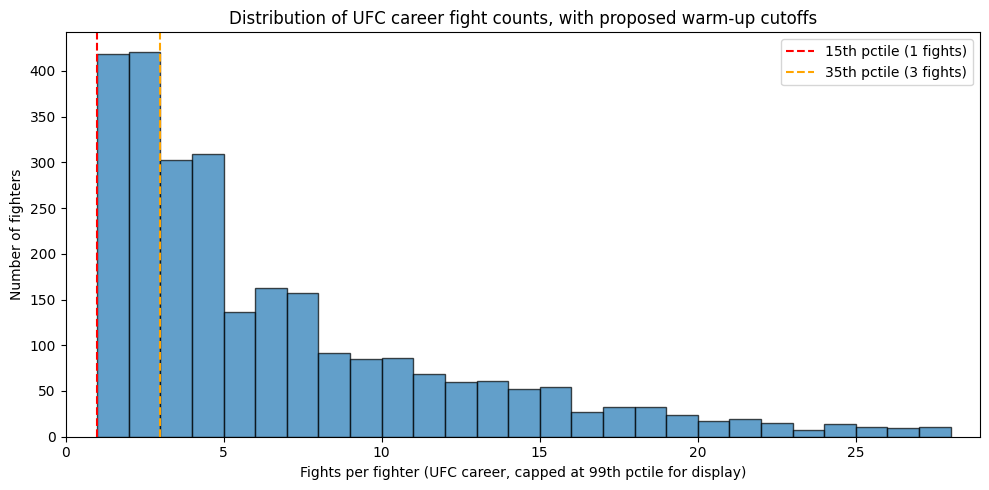

In [ ]:
# BLOCK 14: Fights per fighter histogram

# Get fighter-fight pairs from fight_stats
fighter_fight_pairs = df_fight_stats[['FIGHTER', 'BOUT', 'EVENT']].drop_duplicates(
    subset=['FIGHTER', 'BOUT', 'EVENT']
)
fights_per_fighter = fighter_fight_pairs.groupby('FIGHTER').size().rename('n_fights')

print(f"Fighters with at least one logged fight (from fight_stats): {len(fights_per_fighter):,}")
print(f"Median fights per fighter: {fights_per_fighter.median():.0f}")
print(f"Mean fights per fighter:   {fights_per_fighter.mean():.1f}")
print(f"Max fights per fighter:    {fights_per_fighter.max()}")
print()

# Percentiles for threshold guidance
p10 = fights_per_fighter.quantile(0.10)
p15 = fights_per_fighter.quantile(0.15)
p35 = fights_per_fighter.quantile(0.35)
p40 = fights_per_fighter.quantile(0.40)

print("Percentile cutoffs (raw fight counts):")
print(f"  10th percentile: {p10:.0f} fights")
print(f"  15th percentile: {p15:.0f} fights")
print(f"  35th percentile: {p35:.0f} fights")
print(f"  40th percentile: {p40:.0f} fights")
print()

# Histogram
x_cap = fights_per_fighter.quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(fights_per_fighter, bins=range(1, int(x_cap) + 2), edgecolor='black', alpha=0.7)
ax.axvline(p15, color='red', linestyle='--', label=f'15th pctile ({p15:.0f} fights)')
ax.axvline(p35, color='orange', linestyle='--', label=f'35th pctile ({p35:.0f} fights)')
ax.set_xlabel('Fights per fighter (UFC career, capped at 99th pctile for display)')
ax.set_ylabel('Number of fighters')
ax.set_title('Distribution of UFC career fight counts, with proposed warm-up cutoffs')
ax.legend()
ax.set_xlim(0, x_cap + 1)
plt.tight_layout()
plt.show()


FINDINGS: The distribution is heavily right skewed. The 15th and 35th percentile cutoffs above give the fight counts associated with the target population split. They are not the binding warm-up classification; that is set later, from the Glicko-2 rating deviation directly. These thresholds appear on the diagnostic layer as a plain reliability tag.

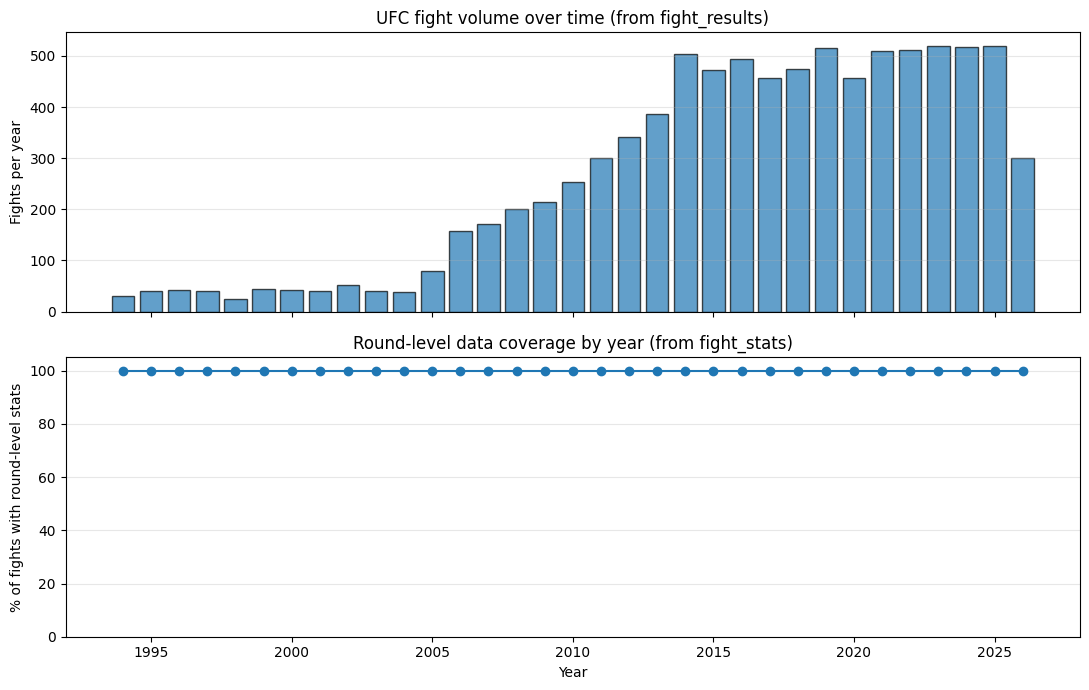


COVERAGE SUMMARY
  Total fights in fight_results: 8,796
  Fights with at least one round-stats row: 8,796 (100.0%)
  Round-level coverage gap: 0 fights


In [ ]:
# BLOCK 15: fights per year + round level coverage gap

# Fight counts by year (from the helper dataframe)
fights_by_year = df_fights_with_dates.dropna(subset=['YEAR']).groupby('YEAR').size()

# Round coverage: a fight has round level stats if at least one row exists
fight_stats_fights = df_fight_stats[['EVENT', 'BOUT']].drop_duplicates()
fight_stats_fights['has_round_stats'] = True

fights_coverage = df_fights_with_dates.merge(
    fight_stats_fights,
    on=['EVENT', 'BOUT'],
    how='left'
)
fights_coverage['has_round_stats'] = fights_coverage['has_round_stats'].fillna(False)

coverage_by_year = fights_coverage.dropna(subset=['YEAR']).groupby('YEAR').agg(
    total_fights=('has_round_stats', 'size'),
    with_round_stats=('has_round_stats', 'sum')
)
coverage_by_year['coverage_pct'] = 100 * coverage_by_year['with_round_stats'] / coverage_by_year['total_fights']

# Plot: two-panel chart
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Top: fights per year
axes[0].bar(fights_by_year.index, fights_by_year.values, edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Fights per year')
axes[0].set_title('UFC fight volume over time (from fight_results)')
axes[0].grid(axis='y', alpha=0.3)

# Bottom: round-level coverage as percentage
axes[1].plot(coverage_by_year.index, coverage_by_year['coverage_pct'], marker='o')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of fights with round-level stats')
axes[1].set_title('Round-level data coverage by year (from fight_stats)')
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Text summary of the coverage gap
total_fights_all = len(df_fight_results)
total_with_round = fights_coverage['has_round_stats'].sum()
print()
print(f"COVERAGE SUMMARY")
print(f"  Total fights in fight_results: {total_fights_all:,}")
print(f"  Fights with at least one round-stats row: {total_with_round:,} ({100*total_with_round/total_fights_all:.1f}%)")
print(f"  Round-level coverage gap: {total_fights_all - total_with_round:,} fights")


FINDINGS: Coverage of round statistics is partial. Modelling that depends on round features (GMM style clustering, the within-fight dominance modifiers) is restricted to the covered subset. The Glicko-2 base rating runs on the full ~8,679 modelable bouts; the diagnostic layers use the subset with round data.

Missing-data percentage per column (fight_results):

  DETAILS                     0.89%   OK (trace)
  REFEREE                     0.30%   OK (trace)
  EVENT                       0.00%   OK
  BOUT                        0.00%   OK
  WEIGHTCLASS                 0.00%   OK
  OUTCOME                     0.00%   OK
  METHOD                      0.00%   OK
  ROUND                       0.00%   OK
  TIME FORMAT                 0.00%   OK
  TIME                        0.00%   OK
  URL                         0.00%   OK
  FIGHT_ID                    0.00%   OK



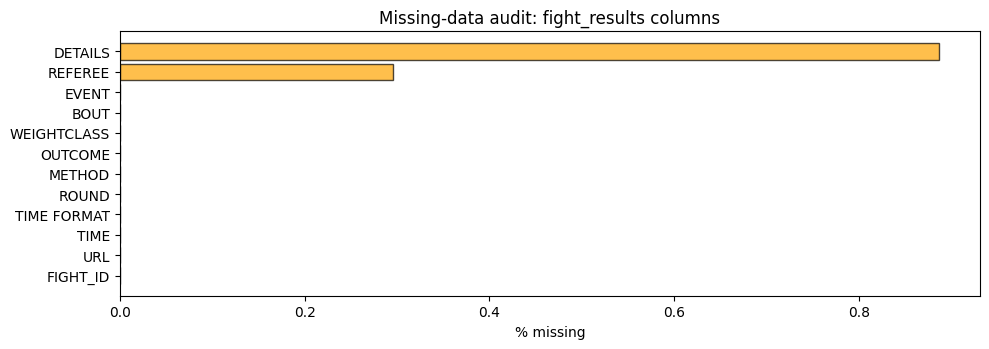

In [ ]:
# BLOCK 16: Check for missing data in fight_results

missing_pct = (df_fight_results.isna().sum() / len(df_fight_results)) * 100
missing_pct = missing_pct.sort_values(ascending=False)

print("Missing-data percentage per column (fight_results):")
print()
for col, pct in missing_pct.items():
    flag = ""
    if pct == 0:
        flag = "OK"
    elif pct < 1:
        flag = "OK (trace)"
    elif pct < 10:
        flag = "MINOR"
    else:
        flag = "MAJOR"
    print(f"  {col:25s}  {pct:5.2f}%   {flag}")

print()

# Plot for visual reference
fig, ax = plt.subplots(figsize=(10, max(3, 0.3 * len(missing_pct))))
colors = ['green' if p == 0 else 'orange' if p < 10 else 'red' for p in missing_pct.values]
ax.barh(missing_pct.index, missing_pct.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('% missing')
ax.set_title('Missing-data audit: fight_results columns')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

FINDINGS: Columns flagged MAJOR or MINOR require explicit null handling in the numeric conversion. Columns at 0% are safe to assume present. Glicko-2 inclusion requires non-null METHOD, OUTCOME, and BOUT; check these are at 0% above.

In [ ]:
# BLOCK 17: Round string parsing audit (fight_stats)

print(f"Total round-level rows: {len(df_fight_stats):,}")
print()

# Check 1: ROUND column format
print("ROUND column inspection")
print(f"  Dtype: {df_fight_stats['ROUND'].dtype}")

# Separate non-null values (the actual round labels) from null values.
round_values = df_fight_stats['ROUND'].dropna()
n_null = df_fight_stats['ROUND'].isna().sum()

print(f"  Unique non-null values: {sorted(round_values.unique())}")
print(f"  Null (NaN) rows: {n_null}")
print(f"  Type inconsistency with fight_results['ROUND'] (int): "
      f"{'YES' if df_fight_stats['ROUND'].dtype == 'object' else 'NO'}")
print()

# Check 2: "X of Y" strike fields
xy_columns = [c for c in df_fight_stats.columns if any(
    kw in c.upper() for kw in ['SIG.STR.', 'TOTAL STR.', 'TD', 'HEAD', 'BODY', 'LEG',
                                'DISTANCE', 'CLINCH', 'GROUND']
)]
# Filter out percentage columns (different format)
xy_columns = [c for c in xy_columns if '%' not in c]

print(f"Candidate 'X of Y' columns ({len(xy_columns)}):")

xy_pattern = re.compile(r'^\d+ of \d+$')

for col in xy_columns[:5]:
    sample = df_fight_stats[col].dropna().astype(str)
    if len(sample) == 0:
        print(f"  {col}: empty")
        continue
    matches = sample.apply(lambda s: bool(xy_pattern.match(s.strip())))
    pct_valid = 100 * matches.sum() / len(matches)
    print(f"  {col:20s}: {pct_valid:.1f}% match 'X of Y' format")
    if pct_valid < 100:
        bad = sample[~matches].head(3).tolist()
        print(f"    Non-matching examples: {bad}")
print()

# Check 3: percentage columns
pct_columns = [c for c in df_fight_stats.columns if '%' in c]
print(f"Percentage columns ({len(pct_columns)}):")
pct_pattern = re.compile(r'^\d{1,3}%$|^---$')

for col in pct_columns:
    sample = df_fight_stats[col].dropna().astype(str)
    matches = sample.apply(lambda s: bool(pct_pattern.match(s.strip())))
    pct_valid = 100 * matches.sum() / len(matches)
    print(f"  {col:20s}: {pct_valid:.1f}% match 'NN%' or '---' format")
    if pct_valid < 100:
        bad = sample[~matches].head(3).tolist()
        print(f"    Non-matching examples: {bad}")
print()

# Check 4: CTRL (control time) mm:ss format
if 'CTRL' in df_fight_stats.columns:
    sample = df_fight_stats['CTRL'].dropna().astype(str)
    ctrl_pattern = re.compile(r'^\d{1,2}:\d{2}$|^---$|^--$')
    matches = sample.apply(lambda s: bool(ctrl_pattern.match(s.strip())))
    pct_valid = 100 * matches.sum() / len(matches)
    print(f"CTRL column: {pct_valid:.1f}% match 'mm:ss', '---', or '--' format")
    if pct_valid < 100:
        bad = sample[~matches].head(3).tolist()
        print(f"  Non-matching examples: {bad}")

Total round-level rows: 41,400

ROUND column inspection
  Dtype: object
  Unique non-null values: ['Round 1', 'Round 2', 'Round 3', 'Round 4', 'Round 5']
  Null (NaN) rows: 42
  Confirmed inconsistency with fight_results['ROUND'] (int) per proposal note: YES

Candidate 'X of Y' columns (9):
  SIG.STR.            : 100.0% match 'X of Y' format
  TOTAL STR.          : 100.0% match 'X of Y' format
  TD                  : 100.0% match 'X of Y' format
  HEAD                : 100.0% match 'X of Y' format
  BODY                : 100.0% match 'X of Y' format

Percentage columns (2):
  SIG.STR. %          : 100.0% match 'NN%' or '---' format
  TD %                : 100.0% match 'NN%' or '---' format

CTRL column: 100.0% match 'mm:ss', '---', or '--' format


FINDINGS: Any column below 100% match needs special handling in the later parsers. Both '---' and '--' appear as null markers in the raw data; parsers should normalise both to NaN before numeric conversion. The count of nulls in the ROUND column above is a separate consideration: those rows have no round number and need a decision on whether to drop them or recover from context.

## Part 2 close: EDA summary

### Key findings

**Warm-up threshold groundwork (from 2.1):**
- Fight count distribution confirmed as heavily right skewed (long tail of career-long competitors, large mass at the low end)
- 15th and 35th percentile fight counts extracted the empirical histogram as first pass diagnostic thresholds
- Binding warm-up classification is set later, from the Glicko-2 rating deviation directly; the fight count thresholds appear on the diagnostic layer only as a plain language reliability tag

**Coverage (from 2.2):**
- Fight volume by year shows the expected ramp from sparse early UFC (1994 onwards) to dense modern era
- Round level stats coverage gap confirmed: round level stats exist for a subset of fights only; coverage rises sharply through the 2000s
- Implications: Glicko-2 runs on the full set of modelable bouts; round level diagnostic features (GMM clustering, within fight dominance modifiers) run on the covered subset only

**Data quality (from 2.3 and 2.4):**
- Missing data audit identifies columns requiring null handling in the numeric conversion
- "X of Y" and percentage column formats hold at 100% across inspected columns
- CTRL column: 100% match once both --- and -- are treated as null markers
- ROUND column: 42 NaN rows out of 41,400 (0.1%); five clean round labels otherwise (Round 1 through Round 5)
- ROUND column type inconsistency between fight_stats (string) and fight_results (int) confirmed; normalisation required in the numeric conversion

### Notes for the numeric conversion

1. String key hygiene: EVENT and BOUT in fight_results and fight_stats both have trailing whitespace from the upstream scraper. Defensive strip on all object columns at load time recommended.
2. CTRL null markers: Treat both `---` and `--` as null when converting mm:ss to seconds.
3. ROUND nulls: 42 rows need a decision before per round analyses.
4. ROUND type normalisation: Cast fight_stats `'Round 1'` etc. to integer 1, 2, 3 to match fight_results.

### Deferred to later stages

- Full per column distributional plots (strike volumes by weight class, accuracy distributions, time to finish histograms) move into the later notebooks where they sit alongside the cleaned data
- Per fighter time since last fight distribution (relevant to Glicko-2 volatility tuning) handled in the rating engine notebook
- Foreign key validation between fight_stats fighters and fighter_details FIGHTER_IDs done at the start of the conversion.


## Data understanding: conclusion

The primary structured source is sound and understood. The six files load with matching schemas, the method and outcome taxonomies are confirmed, and canonical IDs extract cleanly for the joins the later stages depend on. The distribution of fights per fighter, the gaps in coverage, and the quirks in string parsing are all quantified, so the modelling that follows rests on a known base rather than assumptions.

Three things carry forward to the numeric conversion: the strip of trailing whitespace on the join keys, the twin null markers in the control time column, and the handling of the small number of null round values. The distribution of fights per fighter examined here is the empirical basis for the reliability tiers applied later, and the gap in round coverage sets which fighters the round diagnostics can cover. Nothing in the source blocks the modelling; the known issues are all handled downstream.